In [4]:

# THE DETERMINANT - VISUALIZING AREA TRANSFORMATION

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# DETERMINANT FUNCTION

def det_2x2(matrix):

    a, b = matrix[0, 0], matrix[0, 1]
    c, d = matrix[1, 0], matrix[1, 1]

    return a * d - b * c

print("Testing determinant function:\n")

# Test 1: Identity matrix
I = np.array([[1, 0],
              [0, 1]])
print(f"1.Identity matrix:")
print(f"det = {det_2x2(I)} (area unchanged)")

# Test 2: Scaling matrix
S = np.array([[2, 0],
              [0, 3]])
print(f"\n2. Scaling matrix:")
print(f"   det = {det_2x2(S)} (area × 6)")

# Test 3: Rotation matrix
theta = np.radians(45)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print(f"\n3. Rotation matrix (45°):")
print(f"   det = {det_2x2(R):.4f} (area unchanged)")

# Test 4: Singular matrix
singular = np.array([[1, 2],
                     [2, 4]])
print(f"\n4.Singular matrix:")
print(f"   det = {det_2x2(singular)} (Collapsed)")



print("All tests match NumPy:")
print(f"   Identity: {np.isclose(det_2x2(I), np.linalg.det(I))}")
print(f"   Scaling: {np.isclose(det_2x2(S), np.linalg.det(S))}")
print(f"   Rotation: {np.isclose(det_2x2(R), np.linalg.det(R))}")
print(f"   Singular: {np.isclose(det_2x2(singular), np.linalg.det(singular))}")

Testing determinant function:

1.Identity matrix:
det = 1 (area unchanged)

2. Scaling matrix:
   det = 6 (area × 6)

3. Rotation matrix (45°):
   det = 1.0000 (area unchanged)

4.Singular matrix:
   det = 0 (Collapsed)
All tests match NumPy:
   Identity: True
   Scaling: True
   Rotation: True
   Singular: True


In [5]:

# CREATE UNIT SQUARE

def create_unit_square():

    square = np.array([
        [0, 1, 1, 0, 0],
        [0, 0, 1, 1, 0]
    ])
    return square

unit_square = create_unit_square()

print("Unit Square:")
print(f"Shape: {unit_square.shape}")
print(f"\nCorners:")
print(f"  Bottom-left:  ({unit_square[0, 0]}, {unit_square[1, 0]})")
print(f"  Bottom-right: ({unit_square[0, 1]}, {unit_square[1, 1]})")
print(f"  Top-right:    ({unit_square[0, 2]}, {unit_square[1, 2]})")
print(f"  Top-left:     ({unit_square[0, 3]}, {unit_square[1, 3]})")
print(f"\nArea = 1 × 1 = 1")

Unit Square:
Shape: (2, 5)

Corners:
  Bottom-left:  (0, 0)
  Bottom-right: (1, 0)
  Top-right:    (1, 1)
  Top-left:     (0, 1)

Area = 1 × 1 = 1

 Unit square ready for transformation!


In [7]:

# VISUALIZATION FUNCTION

def plot_transformation(original, transformed, matrix, ax, title):

    det = det_2x2(matrix)

    ax.fill(original[0], original[1],
            color='blue', alpha=0.3, edgecolor='blue', linewidth=2,
            label='Original (area=1)')

    color = 'red' if det < 0 else 'green'
    ax.fill(transformed[0], transformed[1],
            color=color, alpha=0.5, edgecolor=color, linewidth=2,
            label=f'Transformed (area={abs(det):.2f})')

    # Draw axes
    ax.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
    ax.grid(True, alpha=0.2)

    # Settings
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('y', fontsize=10)

    # Title with determinant info
    det_sign = "+" if det > 0 else ("-" if det < 0 else "0")
    title_full = f"{title}\ndet = {det:.2f} ({det_sign})"
    ax.set_title(title_full, fontsize=11, fontweight='bold')

    ax.legend(loc='upper right', fontsize=8)


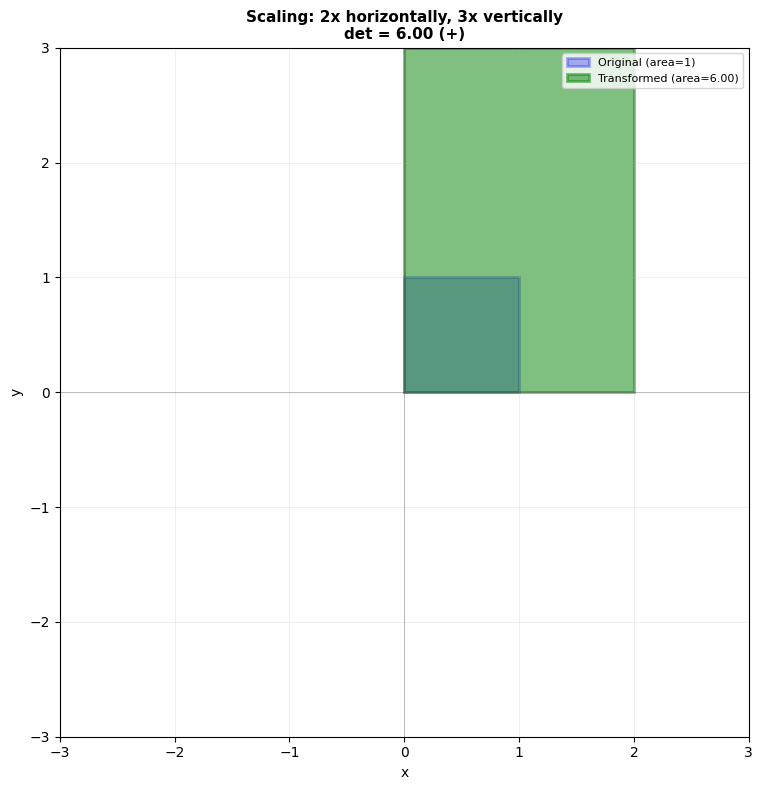

Original area: 1
Transformed area: 6
Area multiplied by: 6


In [9]:

M = np.array([[2, 0],
              [0, 3]])

square = create_unit_square()
transformed = M @ square
#print(transformed)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plot_transformation(square, transformed, M, ax,
                   'Scaling: 2x horizontally, 3x vertically')

plt.tight_layout()
plt.show()

print(f"Original area: 1")
print(f"Transformed area: {det_2x2(M)}")
print(f"Area multiplied by: {det_2x2(M)}")